In [5]:
import numpy as np
import pandas as pd

In [4]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-10-02 22:59:45--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.005s  

2026-10-02 22:59:45 (120 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [9]:
df = pd.read_csv("./02-regression/homework/car_fuel_efficiency_2026.csv")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [11]:
df_modified = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df_modified.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

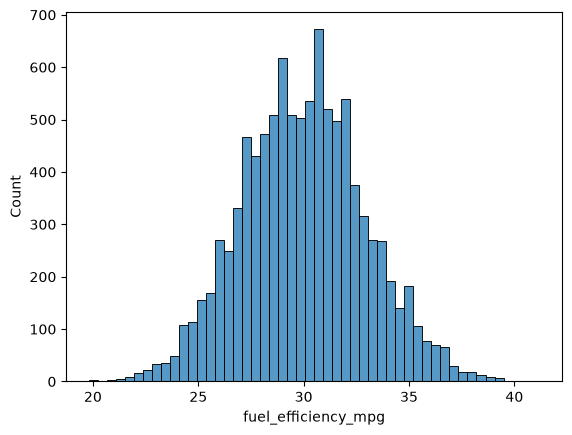

In [13]:
sns.histplot(df_modified.fuel_efficiency_mpg, bins=50)

In [14]:
df.count()

model_year             10000
origin                 10000
fuel_type              10000
drivetrain             10000
num_doors              10000
engine_displacement    10000
num_cylinders          10000
horsepower              9123
vehicle_weight         10000
acceleration            9736
fuel_efficiency_mpg    10000
dtype: int64

In [15]:
df_modified.count()

engine_displacement    10000
horsepower              9123
vehicle_weight         10000
model_year             10000
fuel_efficiency_mpg    10000
dtype: int64

In [18]:
df_modified['horsepower'].median()

np.float64(254.0)

In [19]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

## Question 3

In [53]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [55]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
1,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
2,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
3,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7
...,...,...,...,...,...,...,...,...,...,...,...
5995,2018,Asia,Gasoline,Rear-wheel drive,4,2280,6,242.0,4590,20.5,29.8
5996,1984,Europe,Gasoline,Front-wheel drive,2,2300,6,NaN,4240,18.1,25.1
5997,1989,USA,Gasoline,Front-wheel drive,3,2240,6,255.0,4190,17.2,27.7
5998,2020,Europe,Gasoline,Rear-wheel drive,5,2430,6,254.0,4280,18.4,31.6


In [56]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [60]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [68]:
mean = df_train.horsepower.mean()
mean

np.float64(254.46338337605272)

In [62]:
df_train.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
dtype: object

In [64]:
df_train.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration'],
      dtype='str')

In [65]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [66]:
df_train[base].isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [67]:
df_train[base].fillna(0).isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [70]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [86]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [75]:
def prepare_X_fill_0(df):
    X = df[base].fillna(0).values
    return X

def prepare_X_fill_mean(df):
    X = df[base].fillna(df[base].mean()).values
    return X

In [79]:
# Training
X_train_fill_0 = prepare_X_fill_0(df_train)
w0_fill_0, w_fill_0 = train_linear_regression(X_train_fill_0, y_train)

# Validation
X_val = prepare_X_fill_0(df_val)
y_pred = w0_fill_0 + X_val.dot(w_fill_0)

round(rmse(y_val, y_pred), 3)

np.float64(2.205)

In [80]:
# Training
X_train_fill_mean = prepare_X_fill_mean(df_train)
w0_fill_mean, w_fill_mean = train_linear_regression(X_train_fill_mean, y_train)

# Validation
X_val = prepare_X_fill_mean(df_val)
y_pred = w0_fill_mean + X_val.dot(w_fill_mean)

round(rmse(y_val, y_pred), 3)

np.float64(2.202)

## Question 4

In [81]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [83]:
parameters = [0, 0.01, 0.1, 1, 5, 10, 100]
parameters

[0, 0.01, 0.1, 1, 5, 10, 100]

In [89]:
compare_results = []

for r in parameters:
    w0, w = train_linear_regression_reg(X_train_fill_0, y_train, r=r)

    X_val = prepare_X_fill_0(df_val)
    y_pred = w0 + X_val.dot(w)

    error = round(rmse(y_val, y_pred), 4)
    compare_results.append((r, error))

In [90]:
compare_results

[(0, np.float64(2.2053)),
 (0.01, np.float64(2.2058)),
 (0.1, np.float64(2.2241)),
 (1, np.float64(2.3492)),
 (5, np.float64(2.4094)),
 (10, np.float64(2.4195)),
 (100, np.float64(2.4292))]

## Question 5

In [91]:
def compare_different_seeds(seed):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # Training
    X_train_fill_0 = prepare_X_fill_0(df_train)
    w0_fill_0, w_fill_0 = train_linear_regression(X_train_fill_0, y_train)

    # Validation
    X_val = prepare_X_fill_0(df_val)
    y_pred = w0_fill_0 + X_val.dot(w_fill_0)

    return rmse(y_val, y_pred)

In [99]:
range = np.arange(10)
range

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [100]:
errors = []
for seed in range:
    error = compare_different_seeds(seed)
    errors.append(error)
errors
    

[np.float64(2.239204143046126),
 np.float64(2.2021128210838845),
 np.float64(2.1634197787530947),
 np.float64(2.2043588768539224),
 np.float64(2.2018800943311554),
 np.float64(2.2457851509085134),
 np.float64(2.2697212079524043),
 np.float64(2.190794599933443),
 np.float64(2.216611201686444),
 np.float64(2.2070365928178957)]

In [101]:
round(np.std(errors), 3)

np.float64(0.029)

## Question 6

In [102]:
def train_and_evaluate_on_test(seed, r):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # Prepare full training set
    df_full_train = pd.concat([df_train, df_val])
    df_full_train = df_full_train.reset_index(drop=True)

    # Training
    X_full_train = prepare_X_fill_0(df_full_train)
    y_full_train = np.concatenate([y_train, y_val])
    w0, w = train_linear_regression_reg(X_full_train, y_full_train, r)

    # Test Set Validation
    X_test = prepare_X_fill_0(df_test)
    y_pred = w0 + X_test.dot(w)

    return round(rmse(y_test, y_pred), 3)

In [103]:
train_and_evaluate_on_test(9, 0.001)

np.float64(2.236)